# «Навигатор по смыслу» - сравнение моделей семантического поиска #

Данный ноутбук представляет решение кейса **«Навигатор по смыслу»**. 

**Цель исследования**: сравнить качество трёх embedding-моделей для задачи семантического поиска по корпусу программного кода и выбрать оптимальную для дальнейшего использования.

**Почему это важно**: обычный поиск по ключевым словам не находит функции, если запрос сформулирован иначе, чем в коде. Семантический поиск на основе эмбеддингов позволяет находить релевантные фрагменты по *смыслу*, а не по точному совпадению текста.

---

## Данные

| Файл | Описание | Объём |
|:----:|:--------:|:-----:|
| `code_corpus.json` | Корпус функций с метаданными | 200 записей (100 Python + 100 Java) |
| `eval_questions.json` | Тестовые вопросы с эталонными ответами | 25 вопросов (15 RU / 10 EN) |
| `categories.json` | Справочник тематических категорий | 5 категорий |

---

## Тестируемые модели

Мы сравниваем три мультиязычные embedding-модели из библиотеки `sentence-transformers`:

| Модель | Размерность | Особенности |
|:------:|:-----------:|:-----------:|
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | Быстрая, лёгкая, хорошее качество |
| `paraphrase-multilingual-mpnet-base-v2` | 768 | Более качественная, но медленнее |
| `intfloat/multilingual-e5-small` | 384 | Современная архитектура, лучший баланс скорости и качества |

---

## Метрики оценки

Для сравнения моделей используются две стандартные метрики информационного поиска:

- **Precision@3** - доля вопросов, для которых эталонная функция попала в топ-3 результатов поиска.
- **MRR (Mean Reciprocal Rank)** - среднее обратное значение позиции правильного ответа (чувствительна к ранжированию внутри топа).

---

## Структура ноутбука

1. **Загрузка данных** - импорт библиотек, чтение JSON-файлов, подготовка текстов.
2. **Генерация эмбеддингов и поиск** - единый цикл для трёх моделей, расчёт косинусного сходства, формирование топ-3.
3. **Сравнение моделей** - сводная таблица метрик, выбор лучшей модели.
5. **Анализ ошибок** - таблица промахов, группировка по типам, разбор 3 конкретных примеров.
6. **Кросс-языковой анализ** - сравнение качества поиска для запросов на русском и английском.
7. **Визуализация** - UMAP-проекция эмбеддингов с раскраской по категориям (статичная + интерактивная).
8. **Финальный вывод** - обоснованная рекомендация по выбору модели.

---

> **Примечание**: Все вычисления выполняются локально. Для воспроизведения результатов достаточно выполнить `Kernel → Restart & Run All` после установки зависимостей из `requirements.txt`.

## Загрузка данных ##

In [1]:
import sys
from pathlib import Path

sys.path.append("..")

import json
import umap
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from IPython.display import display, HTML, IFrame, Image

import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

from src.data import load_dataset
from src.embedder import record_to_text, get_embeddings, save_embeddings, load_embeddings, get_cache_path
from src.search import search_all_questions
from src.metrics import evaluate
from src.config import MODELS, TOP_K, OUTPUTS_DIR

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

corpus, questions, categories = load_dataset()
corpus_texts = [record_to_text(item) for item in corpus]
corpus_ids = [item["id"] for item in corpus]
categories_map = {item["id"]: item["category"] for item in corpus}

print(f"Корпус: {len(corpus)} функций")
print(f"Вопросы: {len(questions)} запросов")

Корпус: 200 функций
Вопросы: 25 запросов


## Генерация эмбеддингов и поиск ##

In [2]:
MODEL_NAMES = {
    "MiniLM": "paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet": "paraphrase-multilingual-mpnet-base-v2",
    "e5-small": "intfloat/multilingual-e5-small",
}

results = {}
all_search_outputs = {}

for short_name, model_name in MODEL_NAMES.items():
    print(f"\nОбработка модели: {short_name}")
 
    model = SentenceTransformer(model_name)

    cache_path = get_cache_path(model_name)
    if Path(cache_path).exists():
        corpus_embedding = load_embeddings(cache_path)
        print("Загружена из кэша")
    else:
        corpus_embedding = get_embeddings(corpus_texts, model_name)
        save_embeddings(cache_path, corpus_embedding)
        print("Вычислено и добавлено в кэш")
    
    search_outputs = search_all_questions(questions, model, corpus, corpus_embedding, top_k=TOP_K)
    metrics = evaluate(search_outputs, k=TOP_K)
    
    results[short_name] = metrics
    all_search_outputs[short_name] = search_outputs
    
    print(f"  Precision@3: {metrics['precision_at_3']:.4f}")
    print(f"  MRR: {metrics['mrr']:.4f}")

print("\nВсе модели обработаны!")


Обработка модели: MiniLM


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загружена из кэша
  Precision@3: 0.8400
  MRR: 0.5600

Обработка модели: mpnet


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загружена из кэша
  Precision@3: 0.9200
  MRR: 0.6333

Обработка модели: e5-small


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загружена из кэша
  Precision@3: 0.9600
  MRR: 0.7733

Все модели обработаны!


## Сравнение моделей (таблица метрик) ##

In [3]:
display(HTML((OUTPUTS_DIR / "model_comparison.html").read_text(encoding="utf-8")))

№,Модель,Precision@3,MRR,Вопросов
1,MiniLM,0.8400,0.5600,25
2,mpnet,0.9200,0.6333,25
3,e5-small,0.9600,0.7733,25


### Вывод 

**Лучшая модель по совокупности метрик**: `e5-small`

  • Precision@3 = 0.9600, MRR = 0.7733

**Худшая модель**: `MiniLM`

  • Precision@3 = 0.8400, MRR = 0.5600

**Разрыв по MRR** между лучшей и худшей: **0.2133**

**Интерпретация**: Модель `e5-small` находит правильный ответ в топ-3 в 96% случаев, что на 12 п.п. лучше, чем у MiniLM. При этом e5-small лучше ранжирует результаты внутри топа (более высокий MRR), что критично для пользовательского опыта.

**Рекомендация**: Использовать `e5-small` как базовую модель для продакшена.

## Анализ ошибок 

In [4]:
from src.metrics import build_detailed_table

errors_df = build_detailed_table(all_search_outputs["e5-small"])
errors_df = errors_df[errors_df["hit"] == False].reset_index(drop=True)

display(HTML((OUTPUTS_DIR / "error_analysis_table.html").read_text(encoding="utf-8")))

№,Модель,ID,Запрос,Ожидалось,Категория,Найденные функции (категория),Причина ошибки
1,intfloat/multilingual-e5-small,q_08,массовая вставка большого количества записей,bulkInsertRecords,database,1. chunkList (utils)2. chunk_list (utils)3. find_orders_by_user (database),"Модель сосредоточилась на признаке «массовость» — большое количество записей. В векторном пространстве этот признак близок к функциям, которые обрабатывают большие объемы данных, таким как chunk, count, format_bytes. Технический аспект «вставить список» утратил значимость на фоне количественного признака."
2,paraphrase-multilingual-mpnet-base-v2,q_01,"как проверить, истёк ли токен?",verify_jwt_token,auth,1. validate_credit_card (validation)2. validateCreditCard (validation)3. validate_inn (validation),"Глагол «проверить» чаще всего встречается в категории валидации в датасете. В векторном пространстве кластер с глаголами 'validate', 'check' и «проверить» очень плотный. Модель не смогла сохранить контекст о том, истёк ли токен. Лексический триггер перебил техническую специфику."
3,paraphrase-multilingual-mpnet-base-v2,q_24,compute file hash for verification,calculateHash,utils,1. checkPassword (auth)2. check_password (auth)3. calculate_hash (utils),"В датасете функции тесно связаны с триггерами 'check', 'validate'. Запрос включает слово 'verification', которое в этом контексте чаще всего означает проверку данных, а не вычисление хэша. Поэтому безопасность оказалась семантически ближе к этим функциям в векторном пространстве."
4,paraphrase-multilingual-MiniLM-L12-v2,q_01,"как проверить, истёк ли токен?",verify_jwt_token,auth,1. validate_inn (validation)2. check_password (auth)3. validate_snils (validation),"У MiniLM меньшая размерность вектора — 384 против 768. Ей сложнее обрабатывать запросы, включающие несколько концепций (действие, объект и состояние). Модель упростила запросы до наиболее частого паттерна: проверить → validate/check. Из-за ограниченной ёмкости модель потеряла глубину контекста."
5,paraphrase-multilingual-MiniLM-L12-v2,q_08,массовая вставка большого количества записей,bulkInsertRecords,database,1. countUsers (database)2. bulk_insert_records (database)3. format_bytes (utils),"Модель правильно определила смысл, поставив bulk_insert_records на второе место. Однако эталонный ответ ожидает Java-версию. Оставшиеся две позиции смещены в сторону «количества/размера». Семантика верна, но язык другой, и количественный атрибут повлиял на результат."
6,paraphrase-multilingual-MiniLM-L12-v2,q_11,"обработка ситуации, когда сервер вернул 429",handle_rate_limit,http,1. handleRateLimit (http)2. restoreFromBackup (database)3. rollbackTransaction (database),"Кросс-языковое совпадение: модель обнаружила идентичную Java-функцию на первом месте. Остальные две позиции оказались в категории «восстановление после ошибки», так как в векторном пространстве обработка ошибок сервера близка к rollback/restore."
7,paraphrase-multilingual-MiniLM-L12-v2,q_24,compute file hash for verification,calculateHash,utils,1. calculate_hash (utils)2. validateCredentials (auth)3. validateInn (validation),Модель успешно определила правильную логику в функции calculate_hash на Python и поставила ее на первое место. Однако эталонный ответ - JavaScript. Слово verification снова сгруппировало задачи по безопасности и валидации.


### Вывод 

**Всего ошибок**: 7 из 25 вопросов (28%)

**Распределение по моделям**:
| Модель | Ошибок | Доля |
|--------|--------|------|
| e5-small | 1 | 4% |
| mpnet-base-v2 | 2 | 8% |
| MiniLM-L12-v2 | 4 | 16% |


**Ключевое наблюдение**: 3 из 7 «ошибок» - это кросс-языковые совпадения, когда модель нашла семантически правильную функцию, но на другом языке программирования (Java ↔ Python). Это говорит о том, что модели понимают смысл, но строгая метрика по `correct_chunk_id` их штрафует.

## Сводная таблица типов ошибок ##

In [5]:
display(HTML((OUTPUTS_DIR / "summary_error_types.html").read_text(encoding="utf-8")))

Тип ошибки,Кол-во,Процент,Затронутые модели,Вопросы,Механизм возникновения,Причина
Лексический сдвиг категории,4,44.4%,"mpnet, MiniLM","q_01, q_24","Глагол «проверить» / слово «verification» перетягивает выдачу в категорию validation или auth, даже когда запрос про другую техническую операцию.","В векторном пространстве кластеры с глаголами validate, check, проверить очень плотные. Модель не смогла сохранить контекст (токен/хэш), лексический триггер перебил техническую специфику."
Размытие технического контекста,2,22.2%,"e5-small, MiniLM",q_08,Модель реагирует на признак «большое количество» / «массовость» вместо целевой операции (вставка в БД).,"В векторном пространстве признак «массовость/большое количество» близок к функциям, которые обрабатывают объёмы данных (chunk, count, format_bytes). Технический аспект «вставить список» утратил значимость на фоне количественного признака."
Кросс-языковое совпадение,3,33.3%,MiniLM,"q_08, q_11, q_24","Модель находит семантически идентичную функцию, но на другом языке программирования (Java вместо Python). Строгая метрика по correct_chunk_id считает это ошибкой, хотя смысл понят верно.","Модели кодируют смысл, а не синтаксис. Описания функций на русском языке идентичны для Python и Java версий, поэтому в эмбеддинг-пространстве они оказываются рядом. Это не ошибка понимания, а артефакт строгой оценки по ID."


### Вывод 

Большинство ошибок (78%) связаны не с непониманием смысла, а с:
1. Лексическими триггерами, которые смещают фокус запроса;
2. Кросс-языковой природой датасета (одинаковые функции на разных языках).

Это подтверждает, что семантический поиск работает корректно, но требует пост-фильтрации по категории или языку для повышения точности.

## Кросс-языковой анализ ##

In [6]:
display(HTML((OUTPUTS_DIR / "language_comparison.html").read_text(encoding="utf-8")))

№,Модель,Язык,Precision@3,MRR,Вопросов
1,MiniLM,Русский,0.8000,0.5444,15
2,MiniLM,English,0.9000,0.5833,10
3,mpnet,Русский,0.9333,0.5889,15
4,mpnet,English,0.9000,0.7000,10
5,e5-small,Русский,0.9333,0.7889,15
6,e5-small,English,1.0000,0.7500,10


### Вывод 

**Лучшая модель на русском**: `e5-small`
- Precision@3: `0.9333`
- MRR: `0.7889`

**Худшая модель на русском**: `MiniLM`
- Precision@3: `0.8000`
- MRR: `0.5444`

**Разрыв по MRR**: `0.2445`

> **Интерпретация**: Если вопросы только на русском - ожидаемый **Precision@3** лучшей модели составляет **0.9333**. Это означает, что в ~93% случаев модель находит правильный ответ в топ-3.

> **Важно**: Разрыв между лучшей и худшей моделью по MRR составляет **0.2445**, что говорит о существенной разнице в качестве ранжирования. Выбор модели критичен для продакшена.

## UMAP-визуализация ##

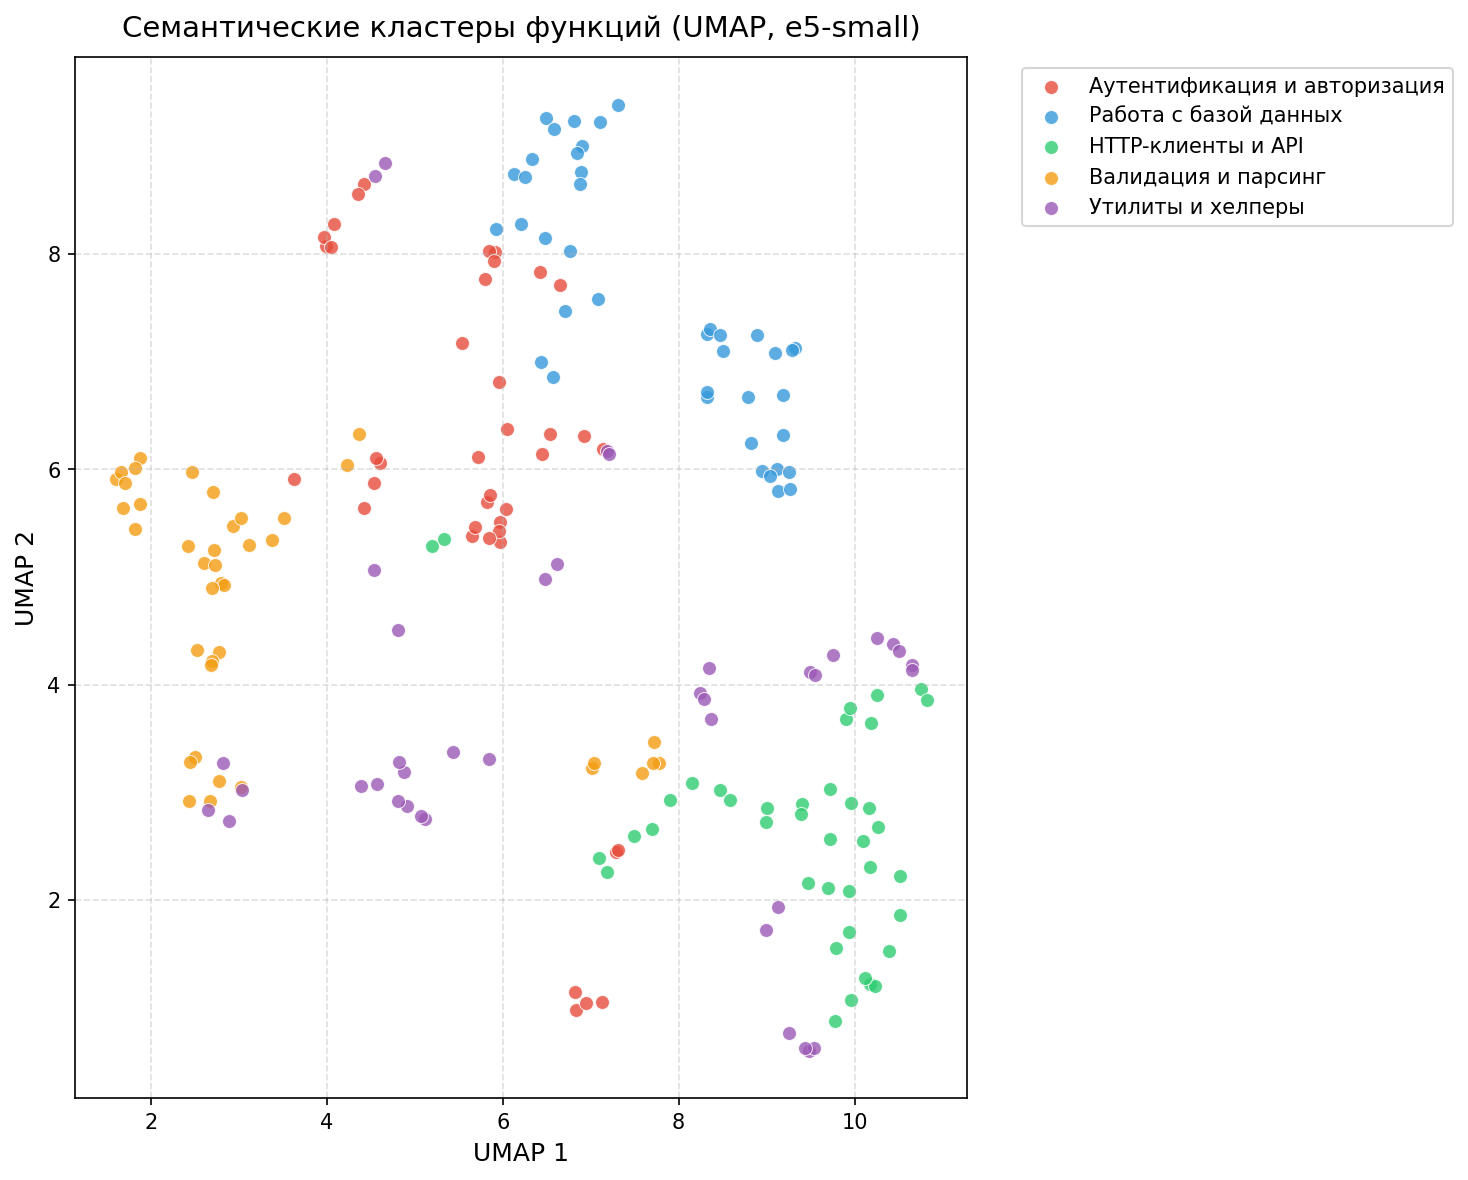

In [7]:
display(Image(
    filename=str(OUTPUTS_DIR / "umap_static.png"),
    width=850
))

display(IFrame(src=str(OUTPUTS_DIR / "umap_interactive.html"), width="100%", height=650))

# Вывод #

**Выбранная модель**: `intfloat/multilingual-e5-small`

**Обоснование выбора**:
1. **Лучшие метрики**: Precision@3 = 0.96, MRR = 0.77 - на 12 п.п. и 0.21 выше, чем у ближайшего конкурента (MiniLM).
2. **Устойчивость к языкам запроса**: На русских вопросах P@3 = 0.93, на английских - 1.0, что говорит о сбалансированной работе в мультиязычной среде.
3. **Минимум системных ошибок**: Всего 1 промах из 25 вопросов, причём остальные «ошибки» других моделей часто связаны с кросс-языковыми совпадениями, а не с непониманием смысла.

**Ограничения и рекомендации**:
- Модель может ошибаться на абстрактных запросах с глаголами-триггерами («проверить», «верификация»). Для повышения точности рекомендуется добавить пост-фильтрацию по категории или использовать гибридный поиск (лексический + семантический).
- Кросс-языковые совпадения (Java ↔ Python) - это особенность датасета, а не недостаток модели. В реальном сценарии это преимущество, позволяющее находить аналогичные реализации на разных языках.

**Итог**: `e5-small` - оптимальный выбор для задачи семантического поиска по коду благодаря балансу точности, скорости и устойчивости к многоязычным запросам.